In [2]:
# To explore and analyze the Titanic dataset, understand its structure and data quality,
# identify patterns and relationships, handle missing values, and generate meaningful insights
# using Python and automated data profiling.

In [ ]:
## 1. Import Libraries

In [12]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [ ]:
## 2. Load Dataset

In [4]:
df = pd.read_csv("Titanic.csv")

In [4]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
## 3. Dataset Overview

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.shape

(891, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# The dataset contains 891 rows and 12 columns. It includes passenger information such as survival status, 
# passenger class, gender, age, fare, and embarkation port.

In [ ]:
## 4. Data Quality Analysis

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [ ]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

missing_table

In [ ]:
## 5. Categorical Analysis

In [11]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [12]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [13]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [14]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [ ]:
## 6. Data Cleaning

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [ ]:
df.drop("Cabin",axis = 1, inplace = True)

In [ ]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [ ]:
df.isnull().sum()

In [ ]:
df.info()

In [ ]:
# Missing Age values were replaced using the median age. Cabin was removed because 
# a large proportion of its values were missing. Missing Embarked values were replaced using the mode.

In [ ]:
## 7. Exploratory Analysis

In [ ]:
df["Survived"].value_counts()

In [13]:
df.groupby("Sex")["Survived"].mean() * 100

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

In [ ]:
df.groupby("Pclass")["Survived"].mean() * 100

In [ ]:
df.groupby("Survived")["Age"].mean()

In [ ]:
df.groupby("Pclass")["Fare"].mean()

In [ ]:
df["Fare"].describe()

In [ ]:
df["Pclass"].value_counts()

In [ ]:
## 8. Visualization

<function matplotlib.pyplot.show(close=None, block=None)>

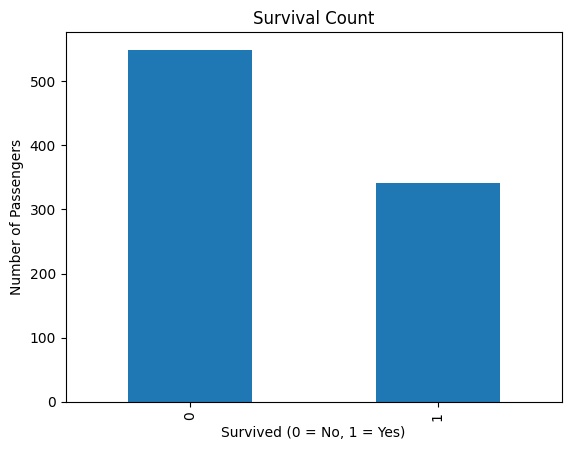

In [15]:
df["Survived"].value_counts().plot(kind = "bar")
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show


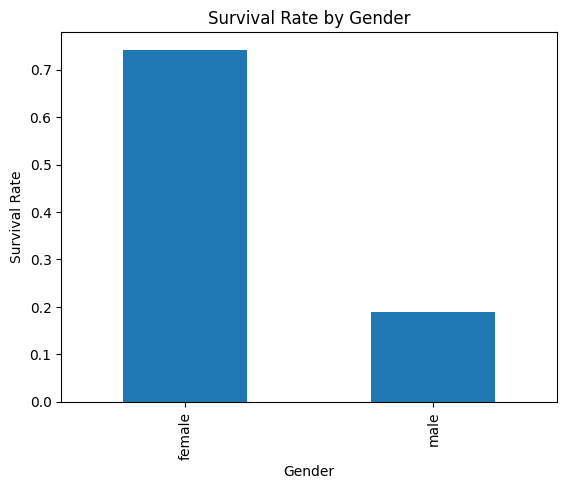

In [17]:
df.groupby("Sex")["Survived"].mean().plot(kind="bar")

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

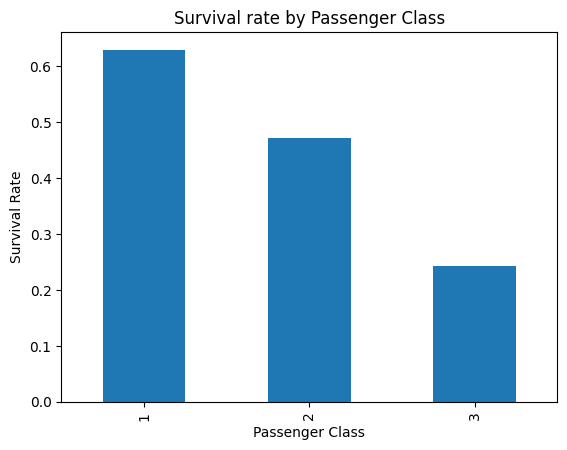

In [19]:
df.groupby("Pclass")["Survived"].mean().plot(kind = "bar")
plt.title("Survival rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

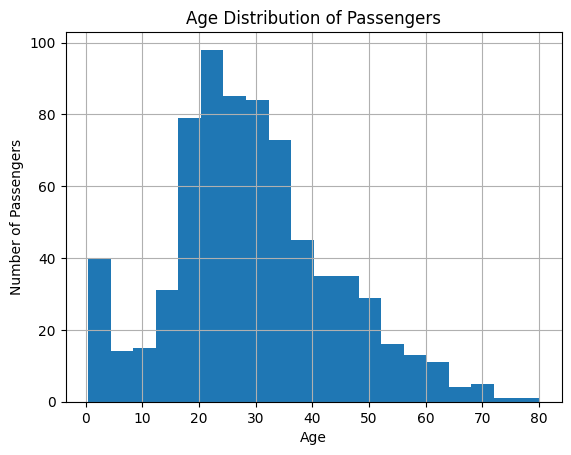

In [20]:
df["Age"].hist(bins=20)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

In [ ]:
## 8. Automated Data Profiling

In [29]:
from data_profiling import ProfileReport

In [30]:
profile = ProfileReport(df, title="Titanic EDA Report")

In [31]:
profile.to_file("titanic_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 53.56it/s][A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## 9. Key Insights

In [ ]:
# 1. Female passengers had a 74.2% survival rate, compared with 18.9% for males.
# 2. First-class passengers had a 63.0% survival rate, compared with 47.3% in second class and 24.2% in third class.
# 3. Third class was the largest passenger group, with 491 passengers (55.1%).
# 4. First-class passengers paid the highest average fare (84.15).
# 5. Fare showed substantial variation, ranging from 0 to 512.33.
# 6. Survivors were slightly younger on average (28.34 years) than non-survivors (30.63 years).
# 7. The original dataset contained significant missing values, particularly in Cabin (687) and Age (177).
# 8. No duplicate rows were found in the original dataset.

In [ ]:
# 10. Conclusion

In [ ]:
# The analysis shows that survival on the Titanic was strongly associated with gender and passenger class. 
# Female and first-class passengers had considerably higher survival rates. The dataset also contained 
# significant missing values, which were handled during preprocessing. Overall, EDA helped identify important patterns,
# data-quality issues, and relationships within the dataset.